
# Fine-Tuning DistilBERT for Yelp Review Sentiment Classification

This notebook fine-tunes `distilbert-base-uncased` on `/content/drive/MyDrive/yelp_reviews_clean_CA.csv` for three-class sentiment classification.

Evaluation follows the project proposal: validation loss is monitored during training, and final test-set performance is reported using accuracy, class-specific precision, recall, F1, macro F1, weighted F1, and a confusion matrix.


In [2]:

# Mount Google Drive
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [3]:

# Install required packages
!pip install -q transformers datasets evaluate accelerate scikit-learn matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00


In [4]:

import os
import json
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

os.environ["TOKENIZERS_PARALLELISM"] = "false"

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


CUDA available: True
GPU: Tesla T4



## 1. File paths and configuration

For a first Colab/T4 run, it is usually better to use a manageable sample. Set `MAX_TOTAL_ROWS = None` to train on the full California file.


In [16]:

input_path = "/content/drive/MyDrive/yelp_reviews_clean_CA.csv"

output_dir = "/content/drive/MyDrive/distilbert_yelp_ca_sentiment_model"
metrics_output_path = "/content/drive/MyDrive/distilbert_yelp_ca_sentiment_metrics.json"
predictions_output_path = "/content/drive/MyDrive/distilbert_yelp_ca_test_predictions.csv"
confusion_matrix_output_path = "/content/drive/MyDrive/distilbert_yelp_ca_confusion_matrix.csv"
confusion_matrix_plot_path = "/content/drive/MyDrive/distilbert_yelp_ca_confusion_matrix.png"
loss_plot_path = "/content/drive/MyDrive/distilbert_yelp_ca_training_validation_loss.png"

# Set to None to use the full CSV.
# For initial testing on Colab, 60_000 to 150_000 total rows is usually more practical.
MAX_TOTAL_ROWS = 120_000

# Maximum number of tokens per review.
MAX_LENGTH = 128

# Training hyperparameters
MODEL_NAME = "distilbert-base-uncased"
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 32
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01

print("Input path:", input_path)
print("Output directory:", output_dir)


Input path: /content/drive/MyDrive/yelp_reviews_clean_CA.csv
Output directory: /content/drive/MyDrive/distilbert_yelp_ca_sentiment_model



## 2. Load the Yelp California reviews




In [13]:

if not os.path.exists(input_path):
    raise FileNotFoundError(f"Could not find file: {input_path}")

df = pd.read_csv(input_path)

print("Loaded shape:", df.shape)
display(df.head())


Loaded shape: (347328, 8)


,review_id,user_id,business_id,business_name,stars,sentiment,date,text
0,ZKvDG2sBvHVdF5oBNUOpAQ,wSTuiTk-sKNdcFyprzZAjg,B5XSoSG3SfvQGtKEGQ1tSQ,Los Padres National Forest,3.0,neutral,2016-03-30,This easter instead of going to Lopez Lake we ...
1,pUycOfUwM8vqX7KjRRhUEA,59MxRhNVhU9MYndMkz0wtw,gebiRewfieSdtt17PTW6Zg,Hibachi Steak House & Sushi Bar,3.0,neutral,2016-07-25,Had a party of 6 here for hibachi. Our waitres...
2,eCiWBf1CJ0Zdv1uVarEhhw,OhECKhQEexFypOMY6kypRw,vC2qm1y3Au5czBtbhc-DNw,Sushi Teri,4.0,positive,2013-09-04,"Yes, this is the only sushi place in town. How..."
3,YbMyvlDA2W3Py5lTz8VK-A,4hBhtCSgoxkrFgHa4YAD-w,bbEXAEFr4RYHLlZ-HFssTA,The Original Habit Burger Grill,5.0,positive,2017-01-02,"Great burgers,fries and salad! Burgers have a ..."
4,L0jv8c2FbpWSlfNC6bbUEA,bFPdtzu11Oi0f92EAcjqmg,IDtLPgUrqorrpqSLdfMhZQ,Helena Avenue Bakery,5.0,positive,2016-10-13,What a great addition to the Funk Zone! Grab a...



## 3. Create sentiment labels




In [14]:

label2id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}
id2label = {v: k for k, v in label2id.items()}

df["label"] = df["sentiment"].map(label2id)

print("Cleaned shape:", df.shape)
print("Sentiment distribution:")
print(df["sentiment"].value_counts())
print("Sentiment distribution (%):")
print((df["sentiment"].value_counts(normalize=True) * 100).round(2))


Cleaned shape: (347328, 9)
Sentiment distribution:
sentiment
positive    252458
negative     66052
neutral      28818
Name: count, dtype: int64
Sentiment distribution (%):
sentiment
positive    72.69
negative    19.02
neutral      8.30
Name: proportion, dtype: float64



## 4. Optional stratified sampling

This keeps the class proportions approximately the same while reducing runtime. Set `MAX_TOTAL_ROWS = None` above to skip this step.

In [17]:

if MAX_TOTAL_ROWS is not None and len(df) > MAX_TOTAL_ROWS:
    df, _ = train_test_split(
        df,
        train_size=MAX_TOTAL_ROWS,
        stratify=df["label"],
        random_state=SEED
    )
    df = df.reset_index(drop=True)

print("Dataset shape after optional sampling:", df.shape)
print(df["sentiment"].value_counts())

Dataset shape after optional sampling: (120000, 9)
sentiment
positive    87223
negative    22821
neutral      9956
Name: count, dtype: int64



## 5. Train / validation / test split

The data are split with stratification so the positive, neutral, and negative classes remain represented in each subset.


In [19]:

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("Train distribution:")
print(train_df["sentiment"].value_counts())
print("Validation distribution:")
print(val_df["sentiment"].value_counts())
print("Test distribution:")
print(test_df["sentiment"].value_counts())


Train shape: (84000, 9)
Validation shape: (18000, 9)
Test shape: (18000, 9)
Train distribution:
sentiment
positive    61056
negative    15975
neutral      6969
Name: count, dtype: int64
Validation distribution:
sentiment
positive    13084
negative     3423
neutral      1493
Name: count, dtype: int64
Test distribution:
sentiment
positive    13083
negative     3423
neutral      1494
Name: count, dtype: int64



## 6. Convert pandas DataFrames to Hugging Face Datasets


In [20]:

# Keep only columns needed for model training
train_dataset = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

dataset = DatasetDict({
    "train": train_dataset,
    "validation": val_dataset,
    "test": test_dataset
})

print(dataset)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 84000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 18000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 18000
    })
})



## 7. Tokenize the reviews


In [21]:

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_dataset


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/84000 [00:00<?, ? examples/s]

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

Map:   0%|          | 0/18000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 84000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 18000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 18000
    })
})


## 8. Load DistilBERT for three-class sentiment classification


In [22]:

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
)


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



## 9. Define evaluation metrics

The final evaluation reports accuracy, class-specific precision/recall/F1, macro F1, and weighted F1. Validation loss is monitored during training and used to select the best checkpoint.


In [23]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted
    }



## 10. Train DistilBERT

The best model is selected based on the lowest validation loss.


In [25]:

training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=LEARNING_RATE,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available()
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

train_result = trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.249242,0.287944,0.902056,0.768450,0.735367,0.743692,0.891998,0.902056,0.894723


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.249242,0.287944,0.902056,0.768450,0.735367,0.743692,0.891998,0.902056,0.894723
2,0.197295,0.286067,0.906222,0.783910,0.761302,0.770965,0.900425,0.906222,0.902869
3,0.157639,0.340841,0.904000,0.775230,0.762584,0.768199,0.899881,0.904000,0.901744


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


## 11. Save the best model


In [26]:

trainer.save_model(output_dir)
tokenizer.save_pretrained(output_dir)

print("Best model saved to:", output_dir)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best model saved to: /content/drive/MyDrive/distilbert_yelp_ca_sentiment_model



## 12. Plot training and validation loss

This helps identify overfitting. If training loss continues decreasing while validation loss increases, the model is likely overfitting.


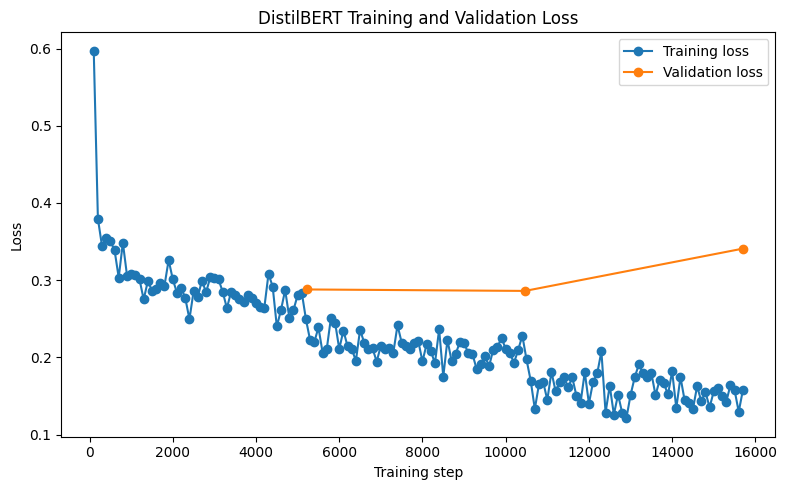

Loss plot saved to: /content/drive/MyDrive/distilbert_yelp_ca_training_validation_loss.png


In [27]:

log_history = trainer.state.log_history

train_loss_steps = []
train_losses = []
validation_epochs = []
validation_losses = []

for log in log_history:
    if "loss" in log and "step" in log:
        train_loss_steps.append(log["step"])
        train_losses.append(log["loss"])
    if "eval_loss" in log and "epoch" in log:
        validation_epochs.append(log["epoch"])
        validation_losses.append(log["eval_loss"])

plt.figure(figsize=(8, 5))

if train_losses:
    plt.plot(train_loss_steps, train_losses, marker="o", label="Training loss")

if validation_losses:
    # Convert epoch values to approximate steps for same x-axis if train steps exist
    if train_loss_steps:
        steps_per_epoch = max(train_loss_steps) / NUM_EPOCHS
        validation_steps = [epoch * steps_per_epoch for epoch in validation_epochs]
        plt.plot(validation_steps, validation_losses, marker="o", label="Validation loss")
    else:
        plt.plot(validation_epochs, validation_losses, marker="o", label="Validation loss")

plt.title("DistilBERT Training and Validation Loss")
plt.xlabel("Training step")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(loss_plot_path, dpi=300)
plt.show()

print("Loss plot saved to:", loss_plot_path)



## 13. Final evaluation on the held-out test set


In [28]:

test_results = trainer.evaluate(tokenized_dataset["test"])

print("Test-set aggregate metrics:")
for key, value in test_results.items():
    print(f"{key}: {value}")


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
0.157639,0.276974,3,0.906611,0.781565,0.768288,0.774300,0.902732,0.906611,0.904497


Test-set aggregate metrics:
eval_loss: 0.2769743502140045
eval_accuracy: 0.9066111111111111
eval_precision_macro: 0.781565120448617
eval_recall_macro: 0.7682877206885262
eval_f1_macro: 0.7743000995906857
eval_precision_weighted: 0.9027318479934742
eval_recall_weighted: 0.9066111111111111
eval_f1_weighted: 0.9044972373422764



## 14. Class-specific precision, recall, and F1


In [29]:

prediction_output = trainer.predict(tokenized_dataset["test"])
logits = prediction_output.predictions
true_labels = prediction_output.label_ids
predicted_labels = np.argmax(logits, axis=-1)

class_names = [id2label[i] for i in range(len(id2label))]

report_dict = classification_report(
    true_labels,
    predicted_labels,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()

display(report_df)

print("Classification report:")
print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=class_names,
        zero_division=0
    )
)


,precision,recall,f1-score,support
negative,0.864108,0.874963,0.869502,3423.000000
neutral,0.524565,0.464525,0.492723,1494.000000
positive,0.956021,0.965375,0.960675,13083.000000
accuracy,0.906611,0.906611,0.906611,0.906611
macro avg,0.781565,0.768288,0.774300,18000.000000
weighted avg,0.902732,0.906611,0.904497,18000.000000


Classification report:
              precision    recall  f1-score   support

    negative       0.86      0.87      0.87      3423
     neutral       0.52      0.46      0.49      1494
    positive       0.96      0.97      0.96     13083

    accuracy                           0.91     18000
   macro avg       0.78      0.77      0.77     18000
weighted avg       0.90      0.91      0.90     18000




## 15. Confusion matrix

The confusion matrix shows which sentiment categories are most frequently confused.


,Predicted negative,Predicted neutral,Predicted positive
True negative,2995,303,125
True neutral,344,694,456
True positive,127,326,12630


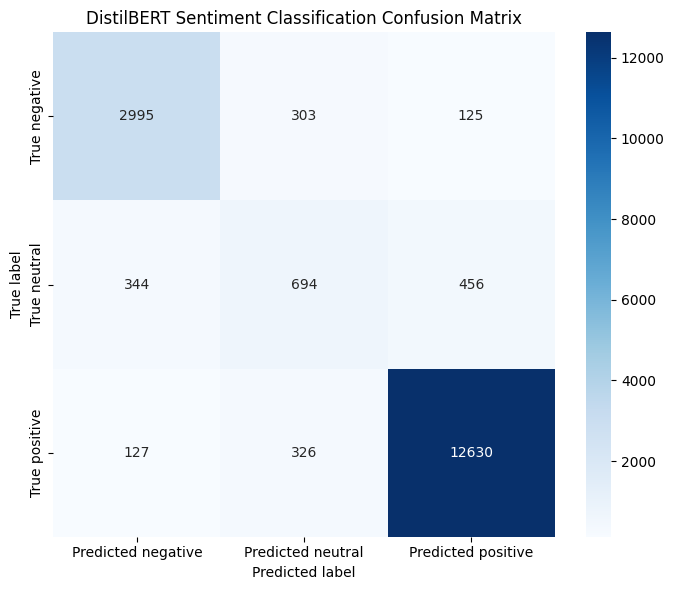

Confusion matrix CSV saved to: /content/drive/MyDrive/distilbert_yelp_ca_confusion_matrix.csv
Confusion matrix plot saved to: /content/drive/MyDrive/distilbert_yelp_ca_confusion_matrix.png


In [30]:

cm = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=[0, 1, 2]
)

cm_df = pd.DataFrame(
    cm,
    index=[f"True {name}" for name in class_names],
    columns=[f"Predicted {name}" for name in class_names]
)

display(cm_df)

cm_df.to_csv(confusion_matrix_output_path, index=True)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("DistilBERT Sentiment Classification Confusion Matrix")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig(confusion_matrix_plot_path, dpi=300)
plt.show()

print("Confusion matrix CSV saved to:", confusion_matrix_output_path)
print("Confusion matrix plot saved to:", confusion_matrix_plot_path)



## 16. Save metrics and test predictions


In [31]:

metrics_to_save = {
    "test_results": {key: float(value) for key, value in test_results.items() if isinstance(value, (int, float, np.floating))},
    "classification_report": report_dict,
    "label_mapping": {
        "label2id": label2id,
        "id2label": {str(k): v for k, v in id2label.items()}
    },
    "model_name": MODEL_NAME,
    "max_length": MAX_LENGTH,
    "max_total_rows": MAX_TOTAL_ROWS,
    "num_epochs": NUM_EPOCHS,
    "train_batch_size": TRAIN_BATCH_SIZE,
    "eval_batch_size": EVAL_BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY
}

with open(metrics_output_path, "w") as f:
    json.dump(metrics_to_save, f, indent=4)

print("Metrics saved to:", metrics_output_path)

# Save test predictions with useful columns
predictions_df = test_df.copy()
predictions_df["true_label_id"] = true_labels
predictions_df["predicted_label_id"] = predicted_labels
predictions_df["true_sentiment"] = [id2label[int(label)] for label in true_labels]
predictions_df["predicted_sentiment"] = [id2label[int(label)] for label in predicted_labels]

# Softmax probabilities
probabilities = torch.nn.functional.softmax(torch.tensor(logits), dim=-1).numpy()
for label_id, label_name in id2label.items():
    predictions_df[f"prob_{label_name}"] = probabilities[:, label_id]

predictions_df.to_csv(predictions_output_path, index=False, encoding="utf-8")
print("Test predictions saved to:", predictions_output_path)

display(predictions_df.head())


Metrics saved to: /content/drive/MyDrive/distilbert_yelp_ca_sentiment_metrics.json
Test predictions saved to: /content/drive/MyDrive/distilbert_yelp_ca_test_predictions.csv


,review_id,user_id,business_id,business_name,stars,sentiment,date,text,label,true_label_id,predicted_label_id,true_sentiment,predicted_sentiment,prob_negative,prob_neutral,prob_positive
0,KocFFnz547q7leTF7eTYaw,HNUsc52-J-nBQsgIyYH2lA,JjmmSW_QQh2Db4fuIEMATA,Persona Pizzeria,5.0,positive,2016-10-28,So let me set the scene.. but family Vacay in ...,2,2,2,positive,positive,0.003994,0.014984,0.981023
1,bkseDorTJadtbNL42uMpWg,xxc0X1l_G3cilYZIzJ_Izw,5d-fkQteaqO6CSCqS5q4rw,Rainbow Nails,5.0,positive,2014-11-09,My nails were fabulous! It was sooo inexpensiv...,2,2,2,positive,positive,0.000101,0.000790,0.999108
2,n8DKMyeWjvczF8A-tQzrKQ,7mRhV_nA0a3J7m40fphNtA,29t8lDBLiwkEd1HA356dOw,Bagel Cafe,5.0,positive,2011-01-25,So where do I begin???! This place is the grea...,2,2,2,positive,positive,0.000274,0.000430,0.999296
3,ADgN61_5FET9vuxjwfzOBA,xgJcIqCtOtp1i6lJNUnTHg,AzZqXglv_puXwd4kCvM7ew,Rudy's,4.0,positive,2020-09-09,I think it's such a big deal that Rudy's went ...,2,2,2,positive,positive,0.073133,0.201116,0.725751
4,RNGdQnryVHFyOlZ9TNJY_w,TfkzGpqVwKde98i5ag1bbQ,DD3TxygdxBxKh9gbjCuLDA,Events By Rincon,5.0,positive,2017-10-17,Many thanks to Angie and her team for an amazi...,2,2,2,positive,positive,0.000134,0.000688,0.999178



## 17. Run inference on new review text


In [32]:

def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )

    device = trainer.model.device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    trainer.model.eval()
    with torch.no_grad():
        outputs = trainer.model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=-1)[0].cpu().numpy()

    predicted_id = int(np.argmax(probs))

    return {
        "predicted_sentiment": id2label[predicted_id],
        "probabilities": {
            id2label[i]: float(probs[i])
            for i in range(len(probs))
        }
    }

example_review = "The food was excellent, but the service was very slow."
predict_sentiment(example_review)


{'predicted_sentiment': 'neutral',
 'probabilities': {'negative': 0.017649265006184578,
  'neutral': 0.6369120478630066,
  'positive': 0.345438688993454}}